In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
df = pd.read_csv(r'C:\Users\LENOVO\Desktop\Github Projects\Diwali Sales Data.csv' , encoding= 'unicode_escape')

In [4]:
df = pd.read_csv('Diwali Sales Data.csv', encoding='unicode_escape')

# Diwali Sales Data Analysis

## Project Objective

The objective of this project is to analyze customer purchasing behavior during the Diwali festival season and identify key customer segments, high-performing product categories, and geographical regions contributing to sales.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## Dataset Information

The dataset contains customer demographic details, purchase information, product categories, and order values during Diwali sales.

In [10]:
df.shape

(11251, 13)

In [11]:
df.head(15)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00
5,1000588,Joni,P00057942,M,26-35,28,1,Himachal Pradesh,Northern,Food Processing,Auto,1,23877.00
6,1001132,Balk,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841.00
7,1002092,Shivangi,P00273442,F,55+,61,0,Maharashtra,Western,IT Sector,Auto,1,NaN
8,1003224,Kushal,P00205642,M,26-35,35,0,Uttar Pradesh,Central,Govt,Auto,2,23809.00
9,1003650,Ginny,P00031142,F,26-35,26,1,Andhra Pradesh,Southern,Media,Auto,4,23799.99


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.1+ MB


In [ ]:
df.drop(['Status','unnamed1'], axis=1, inplace=True)

In [ ]:
df.info()

In [ ]:
pd.isnull(df).sum()

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.shape

In [ ]:
df['Amount']= df['Amount'].astype('int')

In [ ]:
df['Amount'].dtypes

In [ ]:
df.columns

In [14]:
df.rename(columns={'Cust_name':'Customer_name'},inplace=True)

In [15]:
df[['Age', 'Orders', 'Amount']].describe()

,Age,Orders,Amount
count,11251.000000,11251.000000,11239.000000
mean,35.421207,2.489290,9453.610858
std,12.754122,1.115047,5222.355869
min,12.000000,1.000000,188.000000
25%,27.000000,1.500000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12675.000000
max,92.000000,4.000000,23952.000000


# Exploratory Data Analysis

## Gender

In [16]:
df.columns

Index(['User_ID', 'Customer_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

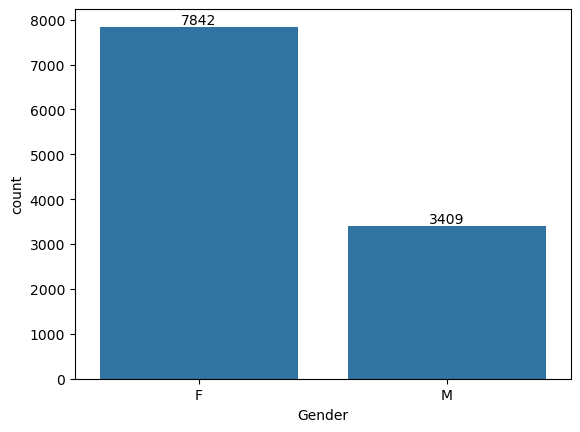

In [17]:
# Plotting a bar chart for Gender and it's count
ax = sns.countplot(x = 'Gender' ,data = df)
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Gender', ylabel='Amount'>

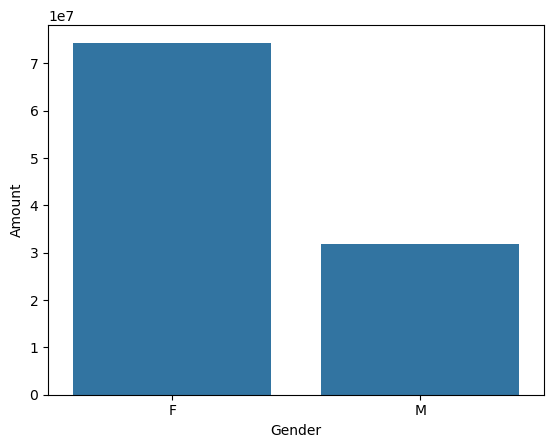

In [18]:
# plotting a bar chart for gender vs total amount
sales_gen = df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)
sns.barplot(x = 'Gender',y= 'Amount' , data = sales_gen)

From above graphs we can see taht most of the buyers are females and even the purchesing power of females are Greater than man

## Sales Distribution

Text(0.5, 1.0, 'Sales Amount Distribution')

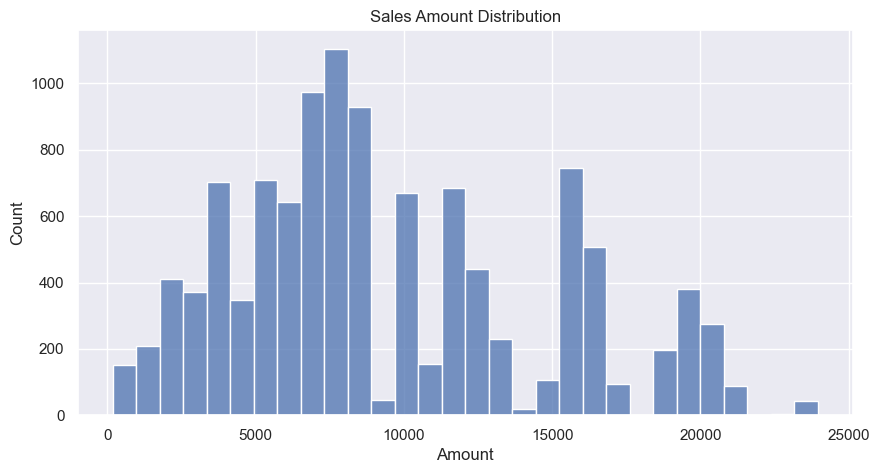

In [31]:
plt.figure(figsize=(10,5))
sns.histplot(df['Amount'], bins=30)
plt.title("Sales Amount Distribution")

# Age

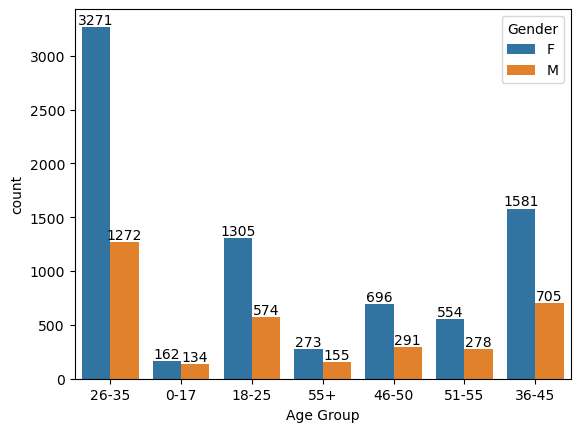

In [19]:
ax = sns.countplot(data = df, x = 'Age Group',hue = 'Gender')

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Age Group', ylabel='Amount'>

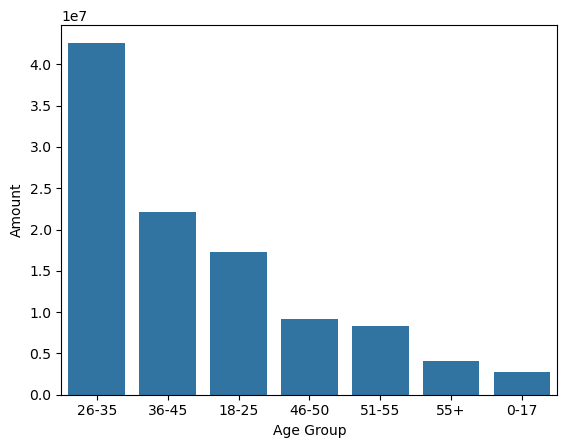

In [20]:
# Total Amount vs Age Group 
sales_age = df.groupby(['Age Group'], as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)
sns.barplot(x = 'Age Group' ,y= 'Amount' ,data = sales_age)

From above graphs we can see that most of the buyers are of age group between 26-35 yrs females 

## State

<Axes: xlabel='State', ylabel='Orders'>

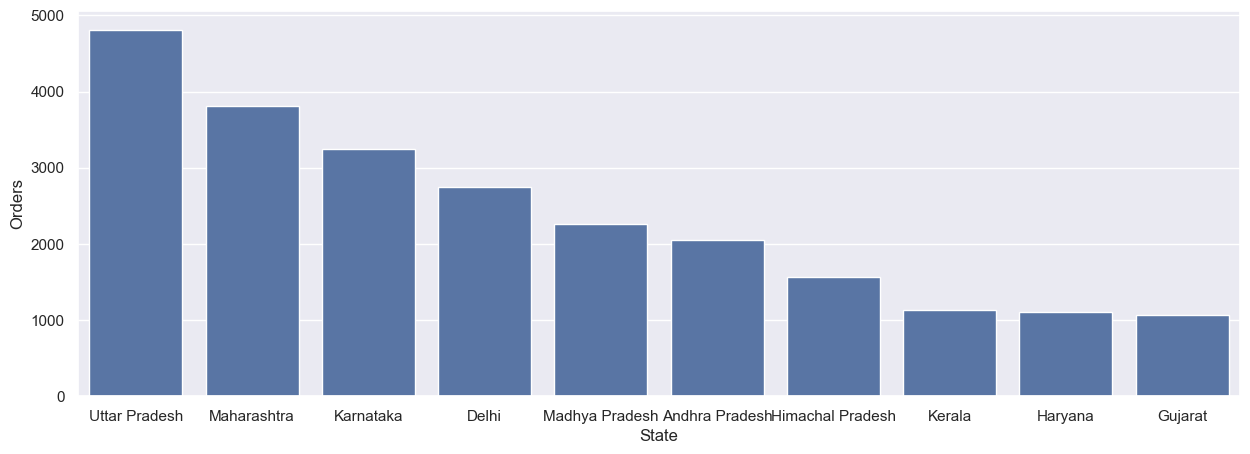

In [21]:
# total number of orders from top 10 states
sales_state = df.groupby(['State'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)
sns.set(rc={'figure.figsize':(15,5)})
sns.barplot(data = sales_state, x = 'State', y= 'Orders')

<Axes: xlabel='State', ylabel='Amount'>

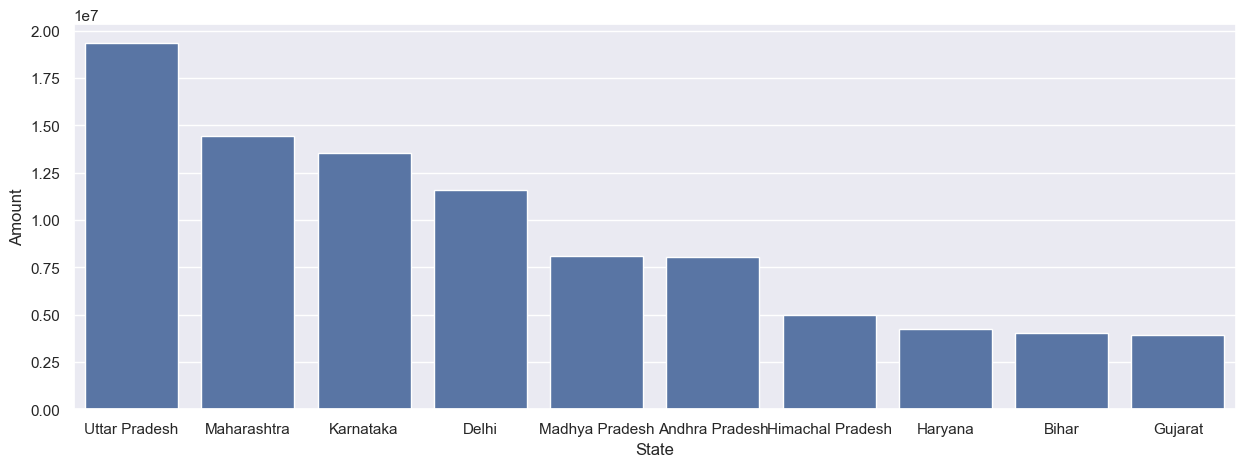

In [22]:
# total amount/sales from top 10 states
sales_state = df.groupby(['State'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False).head(10)
sns.set(rc={'figure.figsize':(15,5)})
sns.barplot(data = sales_state, x = 'State' ,y= 'Amount')

From Above graphs we can see that most of the order & total salse/Amounts are from Uttar pradesh, Maharashtra, Karnataka Respectively

## Marital Status

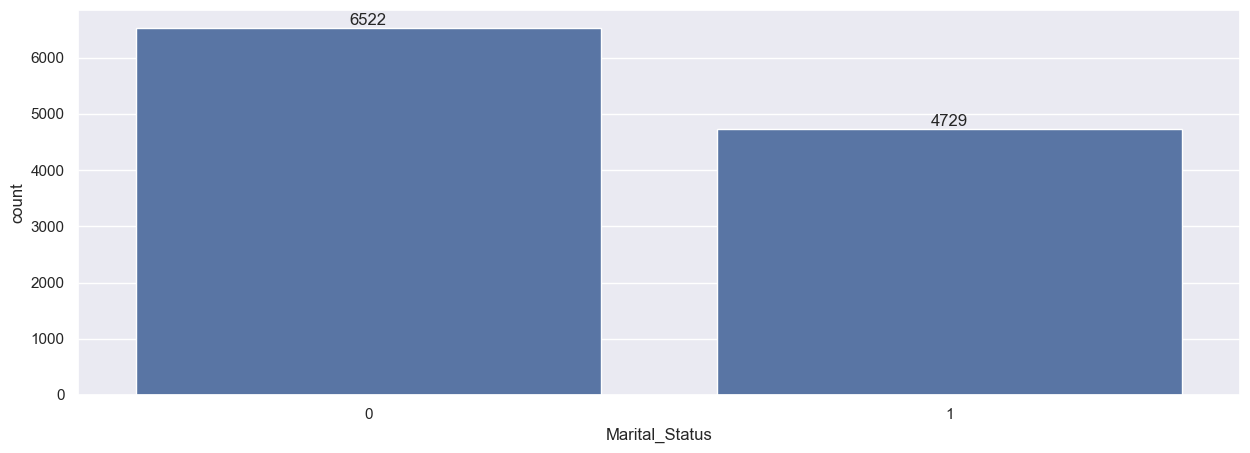

In [23]:
ax = sns.countplot(data =df,x = 'Marital_Status')
sns.set(rc={'figure.figsize':(5,5)})
for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Marital_Status', ylabel='Amount'>

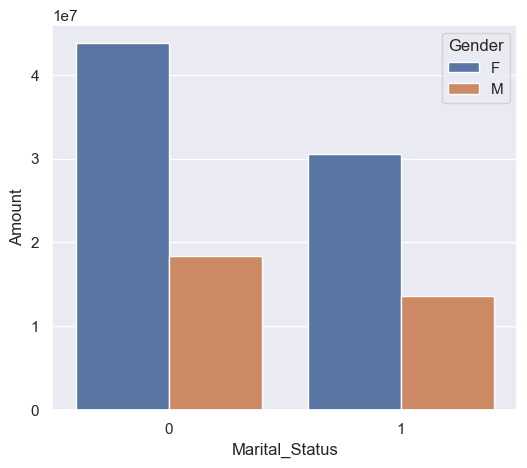

In [24]:
sales_state = df.groupby(['Marital_Status', 'Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.set(rc={'figure.figsize':(6,5)})
sns.barplot(data = sales_state, x = 'Marital_Status',y= 'Amount', hue='Gender')

From above graphs we can see that most of the buyers are married (women) and they have high purchasing power

## Occupation

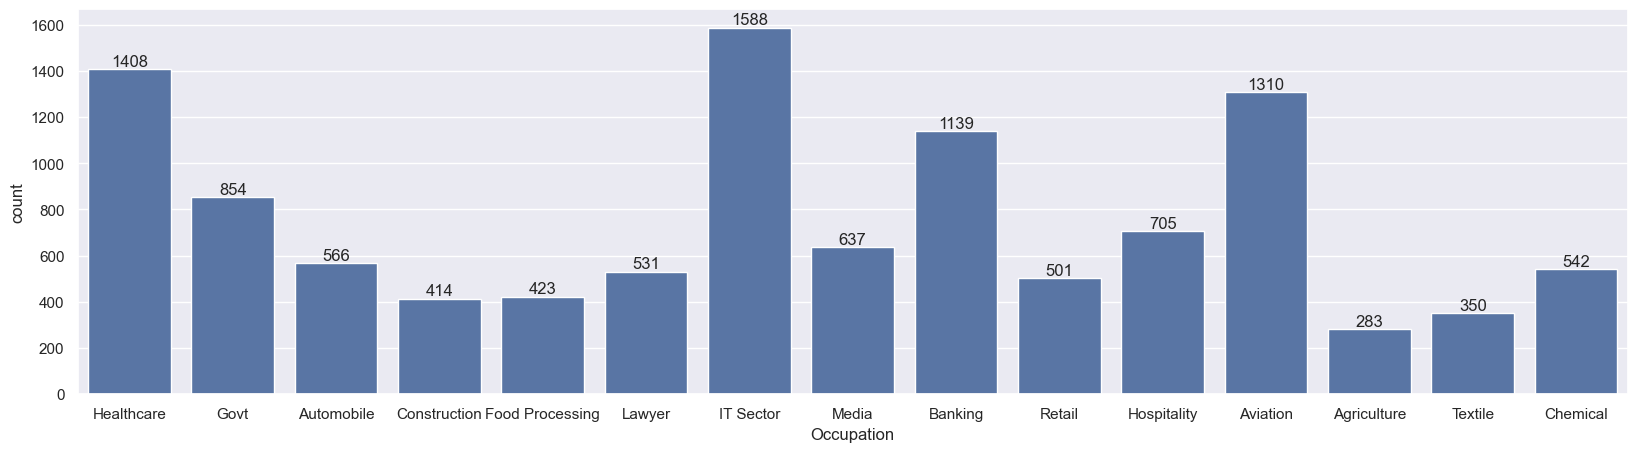

In [25]:
sns.set(rc={'figure.figsize':(20,5)})
ax = sns.countplot(data = df, x = 'Occupation')

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Occupation', ylabel='Amount'>

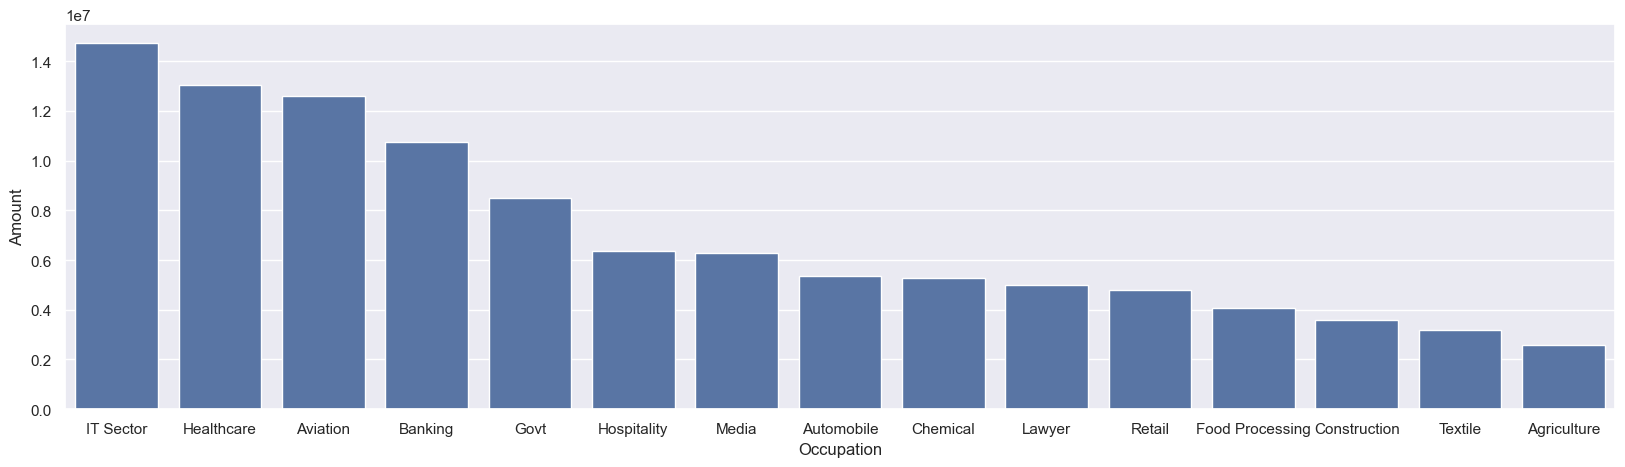

In [26]:
sales_state = df.groupby(['Occupation'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Occupation',y= 'Amount')

From above graphs we can see that most of the buyers are working in IT, Healthcare and Aviation sector

## Product Category

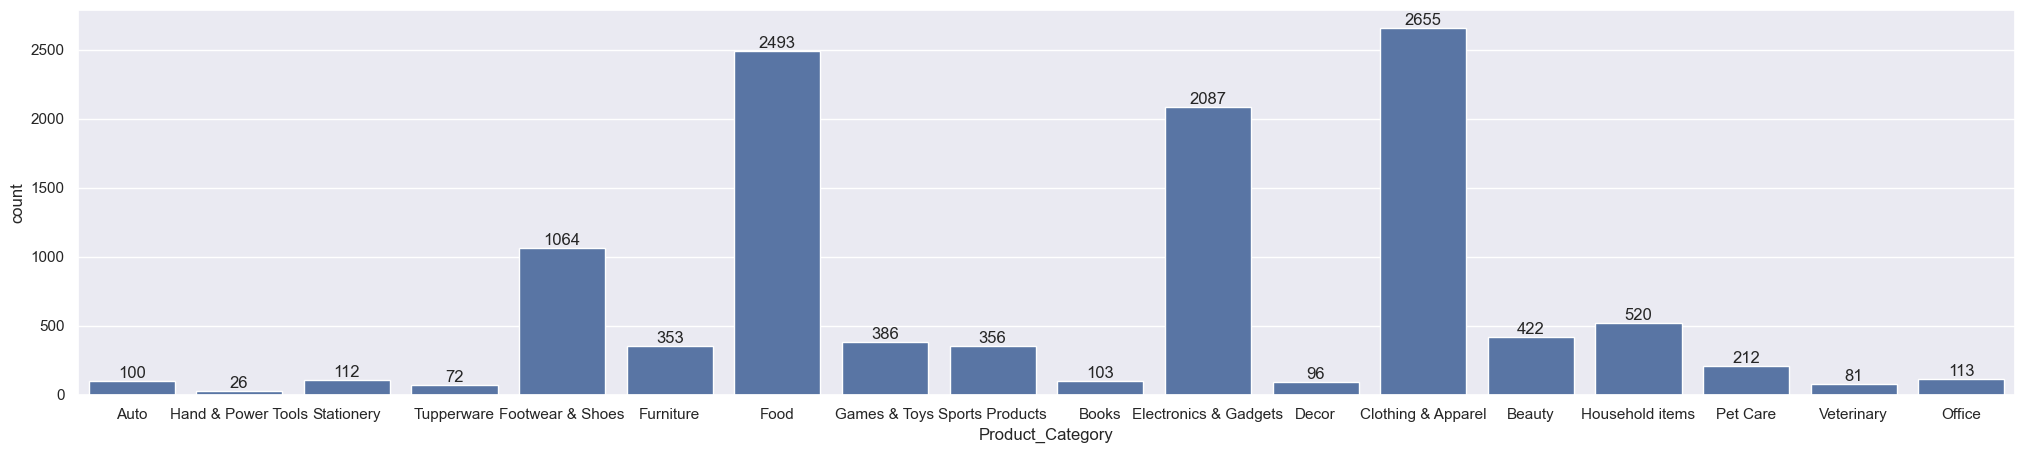

In [27]:
sns.set(rc={'figure.figsize':(25,5)})
ax = sns.countplot(data = df, x = 'Product_Category')

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Product_Category', ylabel='Amount'>

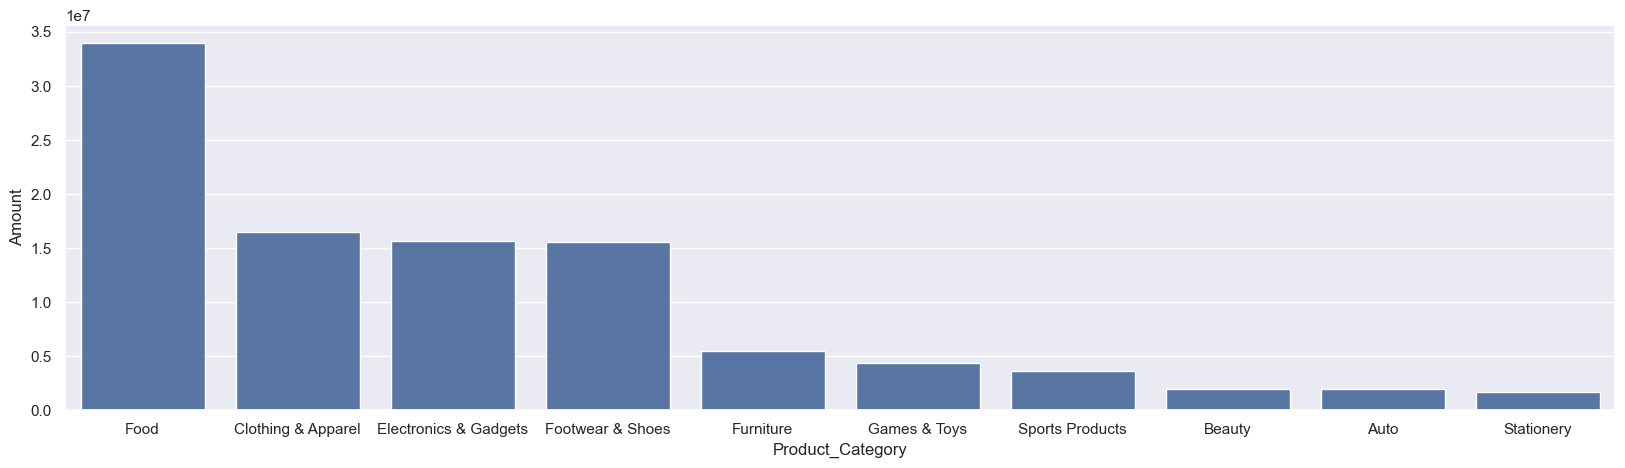

In [28]:
sales_state = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Product_Category',y= 'Amount')

From above graphs we can see that most of the sold products are from Food, Clothing and Electronics category

<Axes: xlabel='Product_ID', ylabel='Orders'>

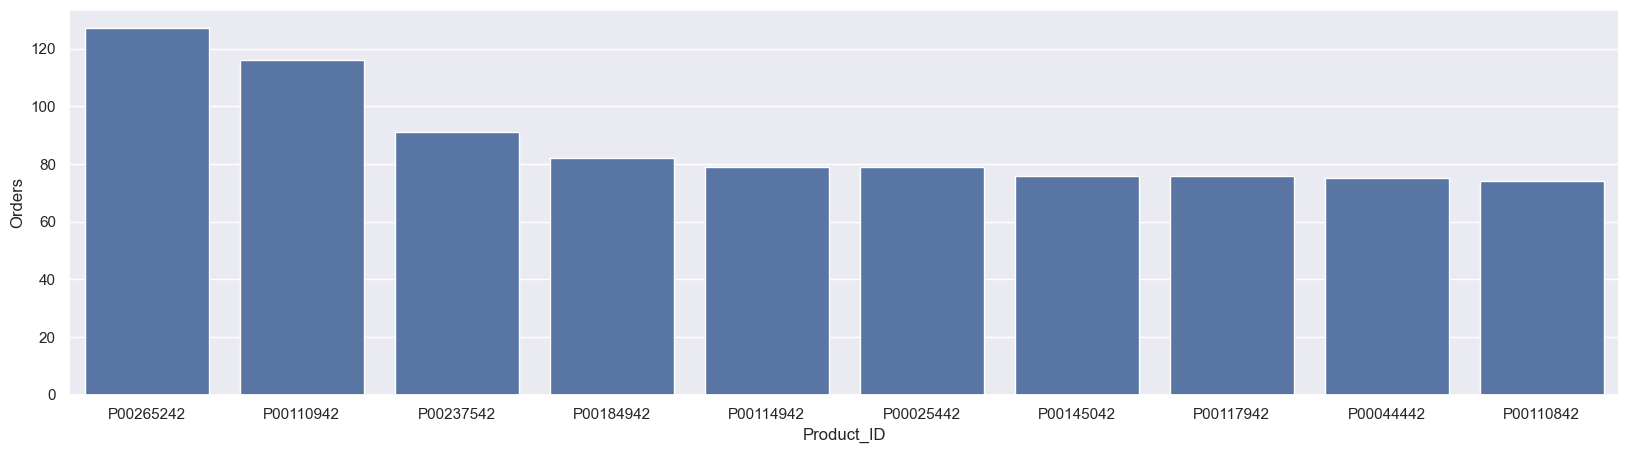

In [29]:
sales_state = df.groupby(['Product_ID'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data = sales_state, x = 'Product_ID',y= 'Orders')

<Axes: xlabel='Product_ID'>

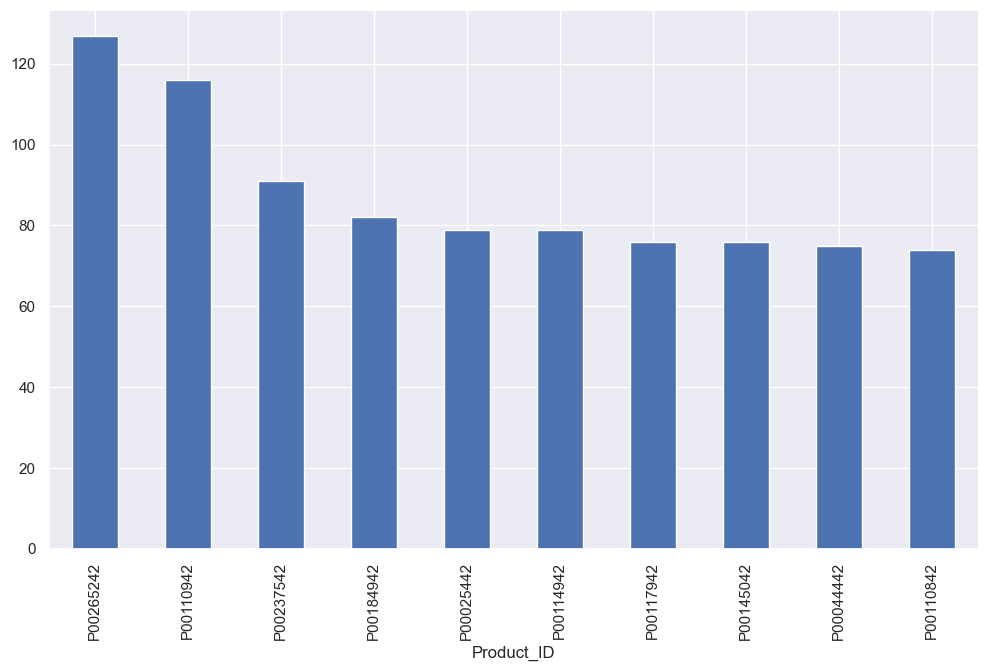

In [30]:
# top 10 most sold products (same thing as above)

fig1, ax1 = plt.subplots(figsize=(12,7))
df.groupby('Product_ID')['Orders'].sum().nlargest(10).sort_values(ascending=False).plot(kind='bar')

## Correlation Heatmap

<Axes: >

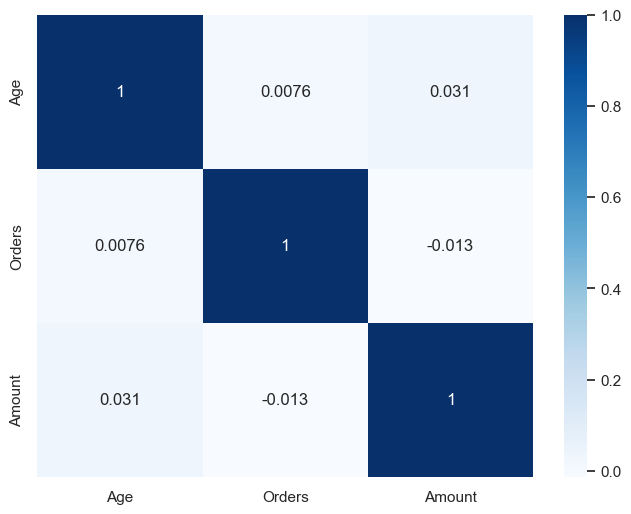

In [32]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Age','Orders','Amount']].corr(),
            annot=True,
            cmap='Blues')

## Top 10 Customers

Text(0.5, 1.0, 'Top 10 Customers by Purchase Amount')

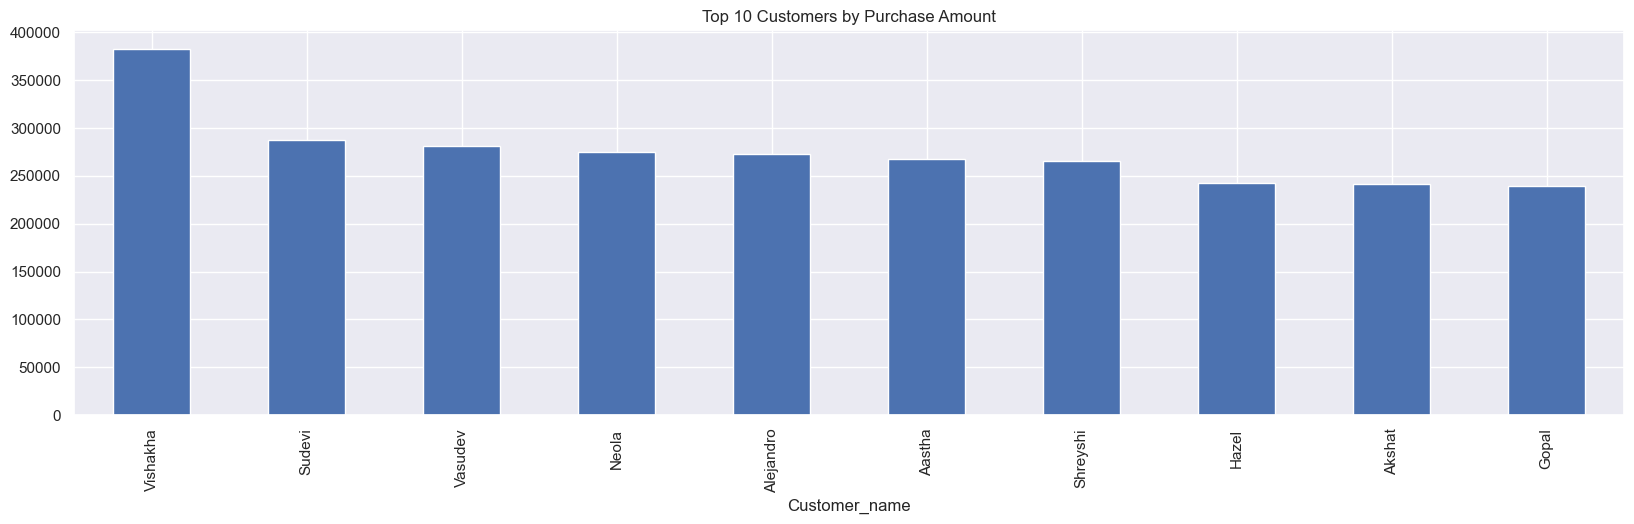

In [33]:
top_customers = df.groupby('Customer_name')['Amount'].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind='bar')
plt.title("Top 10 Customers by Purchase Amount")

Business Insight:

Female customers contribute the highest revenue during Diwali sales, indicating that marketing campaigns targeted toward women may generate higher ROI.

## Top Product Categories Revenue

<Axes: xlabel='Product_Category'>

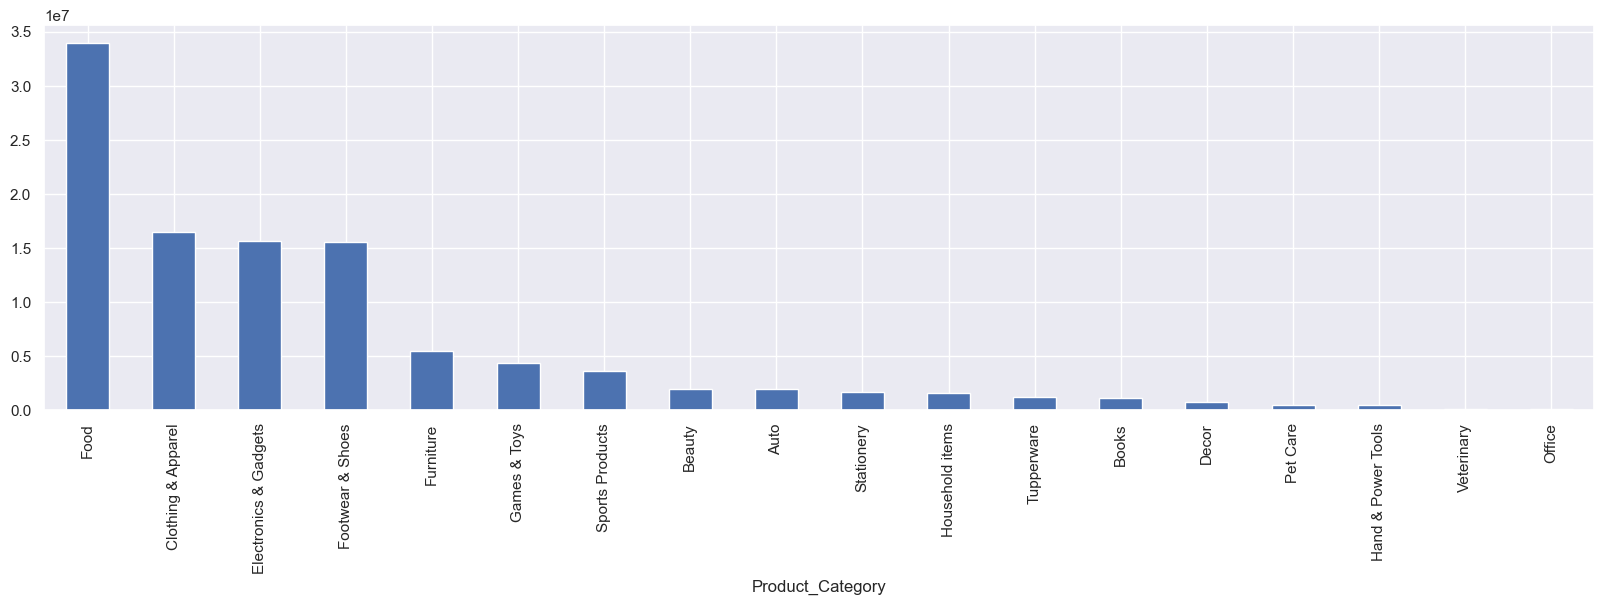

In [34]:
product_sales = df.groupby('Product_Category')['Amount'].sum().sort_values(ascending=False)

product_sales.plot(kind='bar')

# Executive Summary

Key Findings:

1. Female customers generate the highest sales revenue.

2. Customers aged 26-35 contribute significantly to overall sales.

3. Uttar Pradesh, Maharashtra, and Karnataka are the strongest revenue-generating states.

4. Married women represent the most valuable customer segment.

5. Food, Clothing, and Electronics are the top-selling categories.

Business Recommendations:

- Increase marketing spend on female audiences.
- Focus promotions on age group 26-35.
- Expand inventory in top-performing states.
- Bundle food and electronics products during festive campaigns.

## Conclusion:

Married women age group 26-35 yrs from UP, Maharastra and Karnataka working in IT, Healthcare and Aviation are more likely to buy products from Food, Clothing and Electronics category